In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sachin211104/sachin-chess-project/chess_tensor.npy
/kaggle/input/datasets/sachin211104/sachin-chess-project/chess_scalar.parquet


# XGBoost model on scalar features only

Data is balanced using oversampling- blunder   -    221151,
good       -   221151,
inaccuracy  -  221151,
mistake     -  221151,
excellent  -   221151,


2026-05-23 00:38:06.130294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779496686.362863      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779496686.428237      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779496686.982970      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779496686.983014      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779496686.983016      57 computation_placer.cc:177] computation placer alr


Loading scalar dataframe...

Scalar shape: (337981, 21)

Loading tensor file...

Tensor shape: (337981, 12, 8, 8)

========== ORIGINAL CLASS COUNTS ==========

label
good          221151
excellent      57825
inaccuracy     28194
mistake        22817
blunder         7994
Name: count, dtype: int64

========== BALANCED CLASS COUNTS ==========

label
blunder       221151
good          221151
inaccuracy    221151
mistake       221151
excellent     221151
Name: count, dtype: int64

Classes:

['blunder' 'excellent' 'good' 'inaccuracy' 'mistake']

Scalar feature shape:
(1105755, 15)

Train shape:
(884604, 15)

Test shape:
(221151, 15)

Starting XGBoost training...


Training completed.


Models saved successfully.

Test Accuracy: 70.95%


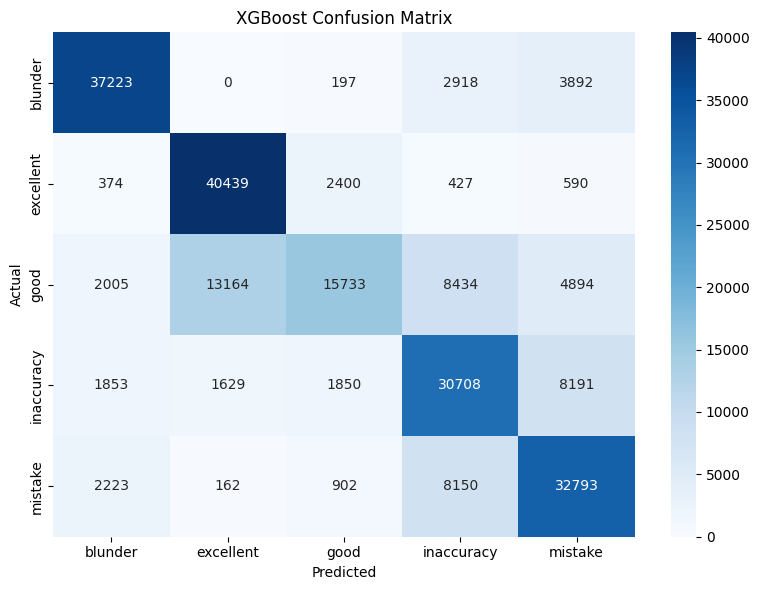


Classification Report:

              precision    recall  f1-score   support

     blunder       0.85      0.84      0.85     44230
   excellent       0.73      0.91      0.81     44230
        good       0.75      0.36      0.48     44230
  inaccuracy       0.61      0.69      0.65     44231
     mistake       0.65      0.74      0.69     44230

    accuracy                           0.71    221151
   macro avg       0.72      0.71      0.70    221151
weighted avg       0.72      0.71      0.70    221151


Top Features:

             Feature  Importance
1               turn    0.909573
8         prev_delta    0.015846
7          prev_eval    0.009974
0        move_number    0.007159
10           avg_elo    0.005909
5           mobility    0.005825
6   material_balance    0.005723
9           elo_diff    0.005253
13          castle_k    0.005248
2         en_passant    0.005243
12          castle_Q    0.005207
14          castle_q    0.004965
11          castle_K    0.004894
3     ha

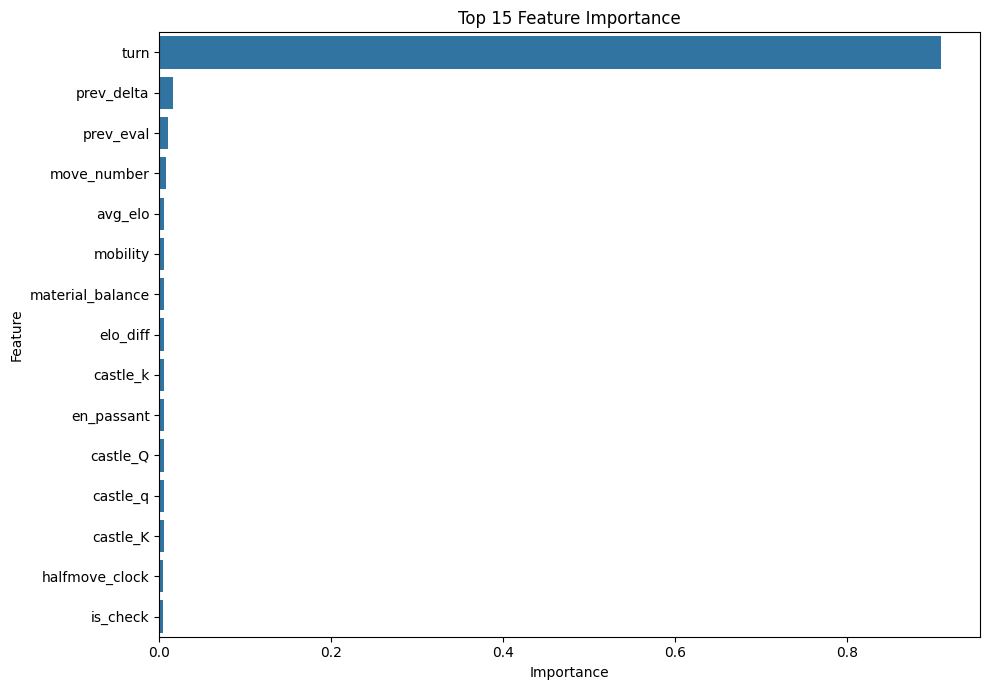


Random Prediction Samples:

   move_number          turn  en_passant  halfmove_clock      is_check  \
0    30.000000 -1.165540e-08        -1.0    3.000000e+00 -3.722983e-09   
1    38.000000 -1.165540e-08        -1.0    1.000000e+00 -3.722983e-09   
2    51.000000  1.000000e+00        -1.0   -6.649762e-08 -3.722983e-09   
3    20.000002 -1.165540e-08        -1.0    1.000000e+00 -3.722983e-09   
4    67.000000  1.000000e+00        -1.0    2.000000e+00  1.000000e+00   

    mobility  material_balance   prev_eval  prev_delta    elo_diff  avg_elo  \
0  26.000000      3.355526e-09  178.000000 -146.000015 -125.000000   1644.5   
1  48.000000     -9.000000e+00 -762.000000 -195.000015 -172.000000   1484.0   
2  13.999999     -6.000000e+00 -643.000000   34.999992 -351.000031   1659.5   
3  32.000000     -5.000000e+00 -420.000031  -21.999994   51.000000   1139.5   
4   2.999999      3.355526e-09  -81.999985  -25.000010  257.999969   1860.0   

       castle_K      castle_Q      castle_k      ca

In [2]:
# ==========================================================
# IMPORTS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from xgboost import XGBClassifier

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

# ==========================================================
# DATASET PATH
# ==========================================================

base_path = "/kaggle/input/datasets/sachin211104/sachin-chess-project/"

# ==========================================================
# LOAD DATA
# ==========================================================

print("\nLoading scalar dataframe...\n")

df = pd.read_parquet(
    base_path + "chess_scalar.parquet"
)

print("Scalar shape:", df.shape)

print("\nLoading tensor file...\n")

X_tensor = np.load(
    base_path + "chess_tensor.npy",
    mmap_mode='r'
)

print("Tensor shape:", X_tensor.shape)

# ==========================================================
# ORIGINAL CLASS COUNTS
# ==========================================================

print("\n========== ORIGINAL CLASS COUNTS ==========\n")

print(
    df["label"].value_counts()
)

# ==========================================================
# CREATE INDEX COLUMN
# ==========================================================

df = df.reset_index(drop=True)

df["idx"] = np.arange(len(df))

# ==========================================================
# OVERSAMPLING
# ==========================================================

max_count = df["label"].value_counts().max()

balanced_indices = []

for label_name in df["label"].unique():

    class_indices = df[
        df["label"] == label_name
    ]["idx"].values

    oversampled_indices = resample(
        class_indices,
        replace=True,
        n_samples=max_count,
        random_state=42
    )

    balanced_indices.extend(
        oversampled_indices
    )

balanced_indices = np.array(
    balanced_indices
)

np.random.shuffle(
    balanced_indices
)

# ==========================================================
# BUILD BALANCED DATAFRAME
# ==========================================================

df_balanced = df.iloc[
    balanced_indices
].reset_index(drop=True)

print("\n========== BALANCED CLASS COUNTS ==========\n")

print(
    df_balanced["label"].value_counts()
)

# ==========================================================
# LABEL ENCODING
# ==========================================================

le = LabelEncoder()

y_encoded = le.fit_transform(
    df_balanced["label"]
)

y = tf.keras.utils.to_categorical(
    y_encoded
)

print("\nClasses:\n")
print(le.classes_)

# ==========================================================
# REMOVE LEAKAGE FEATURES
# ==========================================================

leak_cols = [
    "label",
    "delta",
    "eval",
    "piece_moved",
    "is_capture",
    "gives_check",
    "idx"
]

X_scalar = df_balanced.drop(
    columns=leak_cols
).values

print("\nScalar feature shape:")
print(X_scalar.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_scalar_train, X_scalar_test, \
y_train, y_test = train_test_split(

    X_scalar,
    y,

    test_size=0.2,
    random_state=42,

    stratify=np.argmax(y, axis=1)
)

# ==========================================================
# SCALE FEATURES
# ==========================================================

scaler = StandardScaler()

X_scalar_train = scaler.fit_transform(
    X_scalar_train
)

X_scalar_test = scaler.transform(
    X_scalar_test
)

# ==========================================================
# MEMORY OPTIMIZATION
# ==========================================================

X_scalar_train = X_scalar_train.astype(
    np.float32
)

X_scalar_test = X_scalar_test.astype(
    np.float32
)

# ==========================================================
# LABELS FOR XGBOOST
# ==========================================================

y_train_labels = np.argmax(
    y_train,
    axis=1
)

y_test_labels = np.argmax(
    y_test,
    axis=1
)

print("\nTrain shape:")
print(X_scalar_train.shape)

print("\nTest shape:")
print(X_scalar_test.shape)

# ==========================================================
# BUILD XGBOOST MODEL
# ==========================================================

xgb_model = XGBClassifier(

    objective='multi:softmax',
    num_class=len(le.classes_),

    subsample=0.8,
    reg_lambda=1,
    reg_alpha=0.5,
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    gamma=0.1,
    colsample_bytree=1.0,

    tree_method='hist',

    eval_metric='mlogloss',

    random_state=42,

    n_jobs=-1,

    verbosity=1
)

# ==========================================================
# TRAIN MODEL
# ==========================================================

print("\nStarting XGBoost training...\n")

xgb_model.fit(
    X_scalar_train,
    y_train_labels
)

print("\nTraining completed.\n")

# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(
    xgb_model,
    "/kaggle/working/xgb_scalar_model.pkl"
)

joblib.dump(
    scaler,
    "/kaggle/working/scaler.pkl"
)

joblib.dump(
    le,
    "/kaggle/working/label_encoder.pkl"
)

print("\nModels saved successfully.")

# ==========================================================
# PREDICTIONS
# ==========================================================

y_pred = xgb_model.predict(
    X_scalar_test
)

# ==========================================================
# ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_test_labels,
    y_pred
)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

class_names = [
    str(cls)
    for cls in le.classes_
]

cm = confusion_matrix(
    y_test_labels,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_labels,
        y_pred,
        target_names=class_names
    )
)

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_names = df_balanced.drop(
    columns=leak_cols
).columns.tolist()

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
    xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features:\n")

print(
    importance_df.head(15)
)

# ==========================================================
# FEATURE IMPORTANCE PLOT
# ==========================================================

top_features = importance_df.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance")

plt.tight_layout()
plt.show()

# ==========================================================
# RANDOM TEST PREDICTIONS
# ==========================================================

random_indices = np.random.choice(
    len(y_test_labels),
    100,
    replace=False
)

actual_labels = le.inverse_transform(
    y_test_labels[random_indices]
)

predicted_labels = le.inverse_transform(
    y_pred[random_indices]
)

scalar_original = scaler.inverse_transform(
    X_scalar_test[random_indices]
)

sample_df = pd.DataFrame(
    scalar_original,
    columns=feature_names
)

sample_df["Actual"] = actual_labels
sample_df["Predicted"] = predicted_labels

sample_df["Correct"] = (
    sample_df["Actual"] ==
    sample_df["Predicted"]
)

print("\nRandom Prediction Samples:\n")

print(sample_df.head())

# ==========================================================
# SAVE RANDOM PREDICTIONS
# ==========================================================

sample_df.to_csv(
    "/kaggle/working/xgb_random_predictions.csv",
    index=False
)

print("\n================================================")
print("XGBOOST TRAINING COMPLETED")
print("================================================")